# Uncertainty Quantification with Kernel Density Matrices

This notebook demonstrates how **KDMClassModel** naturally quantifies predictive
uncertainty through its probability-distribution outputs, and contrasts it with a
conventional **softmax classifier** built on the same CNN encoder.

**Experiment:** We apply controlled rotations (0°–345° in 15° steps) to MNIST test
images of digits **'1'** and **'6'** and measure the **Shannon entropy** of the
predicted class distribution at each rotation angle.

Softmax classifiers are notoriously **overconfident** on out-of-distribution inputs —
they maintain high-confidence predictions even for heavily rotated digits. KDM
classifiers become appropriately **uncertain**: when the input falls far from all
learned prototypes, the kernel weights decay to near-uniform, and the output
distribution approaches the uniform (high entropy). No temperature scaling or
post-hoc calibration is needed.

PyTorch implementation of the example described in:
*Kernel Density Matrices for Probabilistic Deep Learning* (González et al., QMI 2025).

In [14]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git

## 1. Imports and Setup

In [15]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF

from kdm.models import KDMClassModel
from kdm.init import init_kdm_layer
from kdm.utils import pure2dm

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
torch.manual_seed(42)
np.random.seed(42)

## 2. Dataset Loading

We use a 20% subset of MNIST training data (~12 000 samples) for a quick demo.
Remove the index slice to use the full 60 000 samples for better accuracy.

In [16]:
mnist_train_full = datasets.MNIST(
    root='~/.cache/mnist', train=True, download=True,
    transform=transforms.ToTensor()
)
mnist_test_ds = datasets.MNIST(
    root='~/.cache/mnist', train=False, download=True,
    transform=transforms.ToTensor()
)

# 20% subset — remove the slice below to train on the full 60k.
# perm = np.random.RandomState(42).permutation(len(mnist_train_full))
# train_idx = perm[:12000]

def stack(ds, idx):
    xs = torch.stack([ds[i][0] for i in idx])
    ys = torch.tensor([ds[i][1] for i in idx], dtype=torch.long)
    return xs, ys

X_train, y_train = stack(mnist_train_full, train_idx)
X_test  = torch.stack([mnist_test_ds[i][0] for i in range(len(mnist_test_ds))])
y_test  = torch.tensor([mnist_test_ds[i][1] for i in range(len(mnist_test_ds))],
                       dtype=torch.long)

print(f"train={X_train.shape}  test={X_test.shape}")

train=torch.Size([12000, 1, 28, 28])  test=torch.Size([10000, 1, 28, 28])


## 3. Model Architectures

Both models share the **same CNN encoder** architecture that maps 28×28 grayscale
images to a 32-dimensional latent vector. The only difference is the **output head**:

| Model | Head | Loss |
|---|---|---|
| Softmax baseline | `Linear(32, 10)` | cross-entropy |
| KDMClassModel | `KDMLayer` + `dm2discrete` | NLL on KDM output |

Using the same encoder isolates the effect of the output head on uncertainty.

In [17]:
ENCODED_SIZE = 32
BASE_DEPTH   = 32
DIM_Y        = 10
N_COMP       = 100
BATCH_SIZE   = 128


def create_encoder(base_depth: int, encoded_size: int) -> nn.Module:
    """Small CNN: (bs,1,28,28) -> (bs, encoded_size)."""
    return nn.Sequential(
        nn.Conv2d(1, base_depth, 5, stride=1, padding=2),              nn.LeakyReLU(),
        nn.Conv2d(base_depth, base_depth, 5, stride=2, padding=2),     nn.LeakyReLU(),
        nn.Conv2d(base_depth, 2*base_depth, 5, stride=1, padding=2),   nn.LeakyReLU(),
        nn.Conv2d(2*base_depth, 2*base_depth, 5, stride=2, padding=2), nn.LeakyReLU(),
        nn.Conv2d(2*base_depth, 4*encoded_size, 7, stride=1, padding=0), nn.LeakyReLU(),
        nn.Flatten(),
        nn.Linear(4*encoded_size, encoded_size),
    )


@torch.no_grad()
def evaluate_base(model, X, y, batch_size=512):
    """Evaluate baseline (logit output) on tensors X, y."""
    model.eval()
    total_loss, n_correct = 0.0, 0
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i+batch_size], y[i:i+batch_size]
        logits = model(xb)
        total_loss += F.cross_entropy(logits, yb).item() * xb.size(0)
        n_correct  += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(X), n_correct / len(X)


@torch.no_grad()
def evaluate_kdm(model, X, y, batch_size=512):
    """Evaluate KDMClassModel (probability output) on tensors X, y."""
    model.eval()
    total_loss, n_correct = 0.0, 0
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i+batch_size], y[i:i+batch_size]
        probs = model(xb)
        total_loss += F.nll_loss(torch.log(probs.clamp_min(1e-12)), yb).item() * xb.size(0)
        n_correct  += (probs.argmax(1) == yb).sum().item()
    return total_loss / len(X), n_correct / len(X)

## 4. Softmax Baseline

A conventional deep classifier: CNN encoder + linear head + softmax.

In [18]:
encoder_base   = create_encoder(BASE_DEPTH, ENCODED_SIZE)
baseline_model = nn.Sequential(encoder_base, nn.Linear(ENCODED_SIZE, DIM_Y))

opt_base  = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)
loader    = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
hist_base = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

EPOCHS_BASE = 5

for ep in range(EPOCHS_BASE):
    baseline_model.train()
    for xb, yb in loader:
        loss = F.cross_entropy(baseline_model(xb), yb)
        opt_base.zero_grad(); loss.backward(); opt_base.step()
    tr_loss, tr_acc = evaluate_base(baseline_model, X_train, y_train)
    te_loss, te_acc = evaluate_base(baseline_model, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_base[k].append(v)
    print(f"epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  test={te_loss:.4f}/{te_acc:.3f}")

epoch  1  train=0.1840/0.947  test=0.1873/0.945
epoch  2  train=0.0894/0.969  test=0.1160/0.963
epoch  3  train=0.0612/0.981  test=0.0878/0.974
epoch  4  train=0.0399/0.988  test=0.0815/0.974
epoch  5  train=0.0270/0.991  test=0.0812/0.975


## 5. KDM Classifier

We initialise the KDM encoder from a **deepcopy** of the trained baseline encoder,
giving both models the same representational starting point. Only the output head
(KDM layer + kernel) is different.

In [19]:
encoder_kdm = copy.deepcopy(encoder_base)   # start from baseline's trained weights
kdm_model   = KDMClassModel(
    encoded_size=ENCODED_SIZE, dim_y=DIM_Y,
    encoder=encoder_kdm, n_comp=N_COMP, sigma=1.0, w_train=True,
)

# Initialise KDM prototypes from a random subset of training encodings.
idx = np.random.randint(X_train.shape[0], size=N_COMP)
encoder_kdm.eval()
with torch.no_grad():
    enc_x = encoder_kdm(X_train[idx])
init_kdm_layer(
    kdm_model.kdm,
    encoded_x=enc_x,
    samples_y=F.one_hot(y_train[idx], DIM_Y).float(),
    init_sigma=True,
)
print(f"Initial sigma: {float(kdm_model.kernel.sigma):.4f}")

opt_kdm  = torch.optim.Adam(kdm_model.parameters(), lr=1e-3)
hist_kdm = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

EPOCHS_KDM = 5
ALPHA = 1.0

for ep in range(EPOCHS_KDM):
    kdm_model.train()
    for xb, yb in loader:
        probs = kdm_model(xb)
        disc_loss = F.nll_loss(torch.log(probs.clamp_min(1e-7)), yb)
        # generative term: log P(x) under the learned KDM marginal over x
        rho_x = pure2dm(kdm_model.encoder(xb))
        gen_loss = -ALPHA * kdm_model.kdm.log_marginal(rho_x).mean()
        loss = disc_loss + gen_loss
        opt_kdm.zero_grad(); loss.backward(); opt_kdm.step()
    tr_loss, tr_acc = evaluate_kdm(kdm_model, X_train, y_train)
    te_loss, te_acc = evaluate_kdm(kdm_model, X_test,  y_test)
    for k, v in [('train_loss', tr_loss), ('test_loss', te_loss),
                 ('train_acc',  tr_acc),  ('test_acc',  te_acc)]:
        hist_kdm[k].append(v)
    print(f"epoch {ep+1:2d}  train={tr_loss:.4f}/{tr_acc:.3f}  "
          f"test={te_loss:.4f}/{te_acc:.3f}  sigma={float(kdm_model.kernel.sigma):.4f}")

Initial sigma: 17.1869
epoch  1  train=0.1788/0.982  test=0.1916/0.976  sigma=17.0918
epoch  2  train=0.1425/0.990  test=0.1629/0.981  sigma=16.9962
epoch  3  train=0.1371/0.993  test=0.1630/0.981  sigma=16.9006
epoch  4  train=0.1165/0.996  test=0.1465/0.984  sigma=16.8050
epoch  5  train=0.1057/0.997  test=0.1387/0.985  sigma=16.7092


## 6. Training Curves

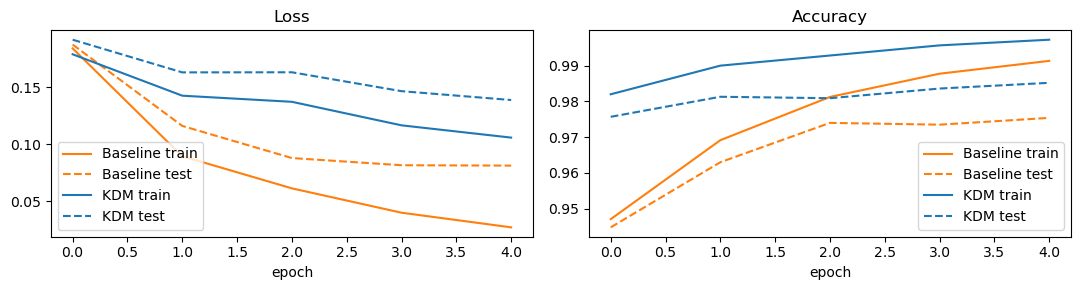

Baseline test accuracy : 0.9754
KDM      test accuracy : 0.9852


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))

axes[0].plot(hist_base['train_loss'], label='Baseline train', color='C1')
axes[0].plot(hist_base['test_loss'],  label='Baseline test',  color='C1', linestyle='--')
axes[0].plot(hist_kdm['train_loss'],  label='KDM train',      color='C0')
axes[0].plot(hist_kdm['test_loss'],   label='KDM test',       color='C0', linestyle='--')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('epoch')

axes[1].plot(hist_base['train_acc'], label='Baseline train', color='C1')
axes[1].plot(hist_base['test_acc'],  label='Baseline test',  color='C1', linestyle='--')
axes[1].plot(hist_kdm['train_acc'],  label='KDM train',      color='C0')
axes[1].plot(hist_kdm['test_acc'],   label='KDM test',       color='C0', linestyle='--')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('epoch')

plt.tight_layout()
plt.show()

_, base_te_acc = evaluate_base(baseline_model, X_test, y_test)
_, kdm_te_acc  = evaluate_kdm(kdm_model,       X_test, y_test)
print(f"Baseline test accuracy : {base_te_acc:.4f}")
print(f"KDM      test accuracy : {kdm_te_acc:.4f}")

## 7. Rotation Experiment

We select one test image of digit **'1'** and one of **'6'**:

- **'1'** is nearly rotationally symmetric → we expect **low, flat** uncertainty.
- **'6'** is asymmetric: at ~180° it resembles a **'9'** → uncertainty should spike
  and the model should hedge between classes 6 and 9.

For each digit we generate 24 rotated copies (0°, 15°, …, 345°) using
`torchvision.transforms.functional.rotate`, which applies bilinear interpolation
and fills out-of-bounds pixels with black (matching the MNIST background).

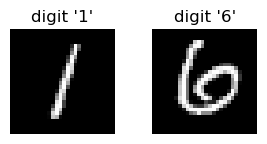

In [21]:
def first_of_digit(X, y, digit):
    """Return the first test image of the given digit as (1,1,28,28)."""
    idx = (y == digit).nonzero(as_tuple=True)[0][0]
    return X[idx:idx+1]

img_1 = first_of_digit(X_test, y_test, 1)
img_6 = first_of_digit(X_test, y_test, 6)

fig, axes = plt.subplots(1, 2, figsize=(3, 1.5))
axes[0].imshow(img_1[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title("digit '1'"); axes[0].axis('off')
axes[1].imshow(img_6[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title("digit '6'"); axes[1].axis('off')
plt.tight_layout()
plt.show()

In [22]:
ANGLES = list(range(0, 360, 15))   # 24 angles: 0, 15, ..., 345


def rotate_batch(img, angles):
    """Rotate a (1,1,H,W) image by each angle. Returns (len(angles),1,H,W)."""
    return torch.stack([TF.rotate(img[0], float(a), fill=0.0) for a in angles])


@torch.no_grad()
def predict_rotations(model, img, angles, is_logit=False):
    """
    Run model on all rotations of img.

    Args:
        is_logit: True for the softmax baseline (output needs softmax),
                  False for KDMClassModel (already returns probabilities).

    Returns:
        probs   (n_angles, 10)  -- class probabilities
        entropy (n_angles,)     -- Shannon entropy H(p)
        conf    (n_angles,)     -- max probability (confidence)
    """
    model.eval()
    rotated = rotate_batch(img, angles)      # (24, 1, 28, 28)
    out = model(rotated)
    probs = F.softmax(out, dim=1).cpu().numpy() if is_logit else out.cpu().numpy()
    eps = 1e-12
    entropy = -(probs * np.log(probs + eps)).sum(axis=1)
    conf    = probs.max(axis=1)
    return probs, entropy, conf


# Run predictions for both models and both digits.
kdm_probs_1,  kdm_entropy_1,  kdm_conf_1  = predict_rotations(kdm_model,      img_1, ANGLES)
kdm_probs_6,  kdm_entropy_6,  kdm_conf_6  = predict_rotations(kdm_model,      img_6, ANGLES)
base_probs_1, base_entropy_1, base_conf_1 = predict_rotations(baseline_model, img_1, ANGLES, is_logit=True)
base_probs_6, base_entropy_6, base_conf_6 = predict_rotations(baseline_model, img_6, ANGLES, is_logit=True)

## 8. Visualisation

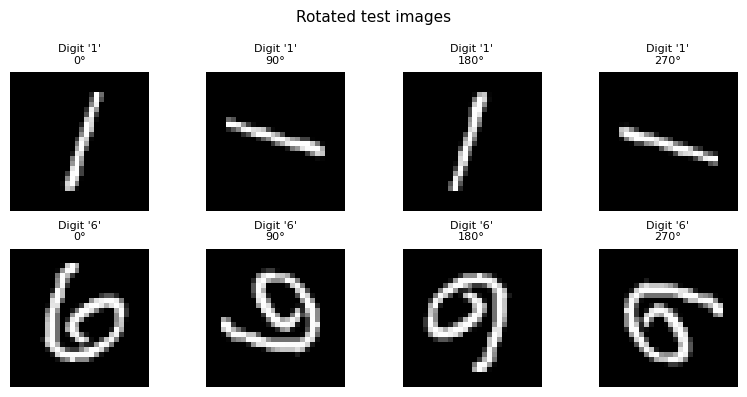

In [23]:
# Image strip: show both digits at 0°, 90°, 180°, 270°.
showcase_angles = [0, 90, 180, 270]

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for row, (img, label) in enumerate([(img_1, "Digit '1'"), (img_6, "Digit '6'")]):
    frames = rotate_batch(img, showcase_angles)
    for col, (ax, angle) in enumerate(zip(axes[row], showcase_angles)):
        ax.imshow(frames[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f"{label}\n{angle}\u00b0", fontsize=8)
        ax.axis('off')
plt.suptitle("Rotated test images", fontsize=11)
plt.tight_layout()
plt.show()

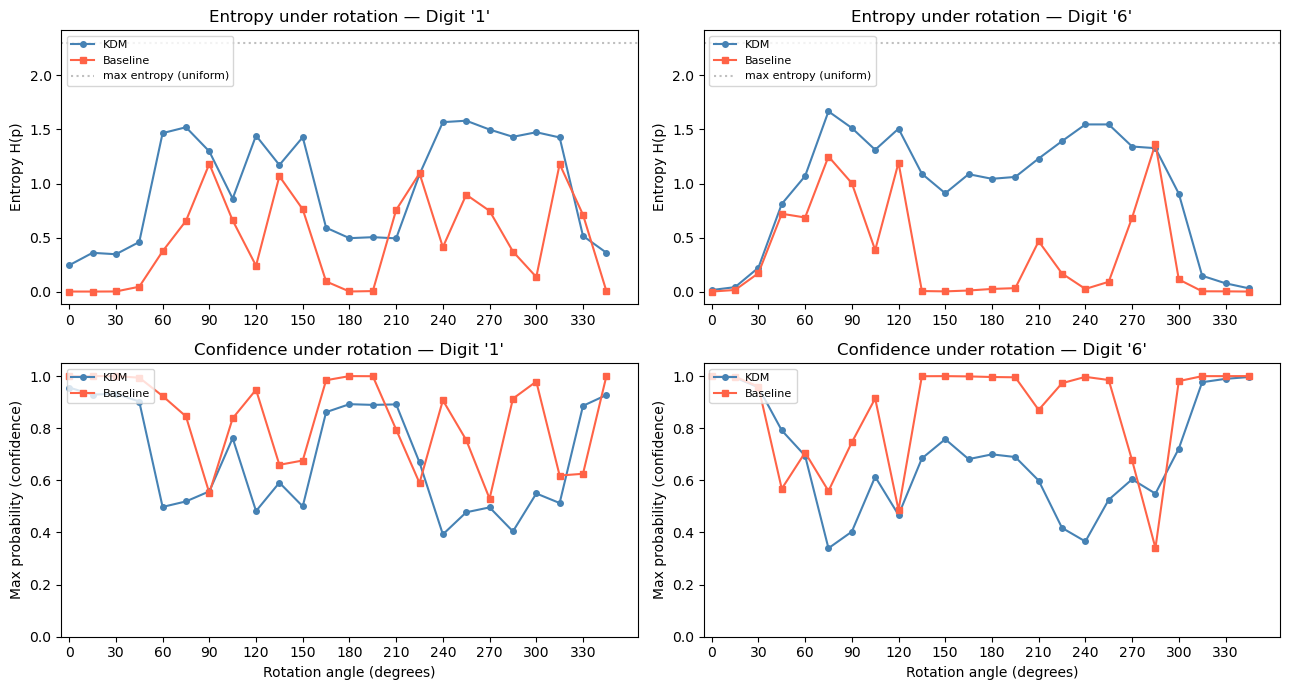

In [24]:
# Uncertainty curves: KDM vs. Baseline, one panel per digit, separate rows for entropy and confidence.

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

max_entropy = np.log(10)   # theoretical maximum for 10 classes (uniform distribution)

for col, (kdm_h, base_h, kdm_c, base_c, label) in enumerate([
    (kdm_entropy_1, base_entropy_1, kdm_conf_1, base_conf_1, "Digit '1'"),
    (kdm_entropy_6, base_entropy_6, kdm_conf_6, base_conf_6, "Digit '6'"),
]):
    ax_ent  = axes[0, col]
    ax_conf = axes[1, col]

    # --- Entropy row ---
    ax_ent.plot(ANGLES, kdm_h,  color='steelblue', marker='o', ms=4, label='KDM')
    ax_ent.plot(ANGLES, base_h, color='tomato',    marker='s', ms=4, label='Baseline')
    ax_ent.axhline(max_entropy, color='gray', linestyle=':', alpha=0.5,
                   label='max entropy (uniform)')
    ax_ent.set_ylabel('Entropy H(p)')
    ax_ent.set_title(f"Entropy under rotation — {label}")
    ax_ent.set_xticks(ANGLES[::2])
    ax_ent.set_xlim(-5, 365)
    ax_ent.legend(loc='upper left', fontsize=8)

    # --- Confidence row ---
    ax_conf.plot(ANGLES, kdm_c,  color='steelblue', marker='o', ms=4, label='KDM')
    ax_conf.plot(ANGLES, base_c, color='tomato',    marker='s', ms=4, label='Baseline')
    ax_conf.set_ylabel('Max probability (confidence)')
    ax_conf.set_ylim(0, 1.05)
    ax_conf.set_xlabel('Rotation angle (degrees)')
    ax_conf.set_title(f"Confidence under rotation — {label}")
    ax_conf.set_xticks(ANGLES[::2])
    ax_conf.set_xlim(-5, 365)
    ax_conf.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


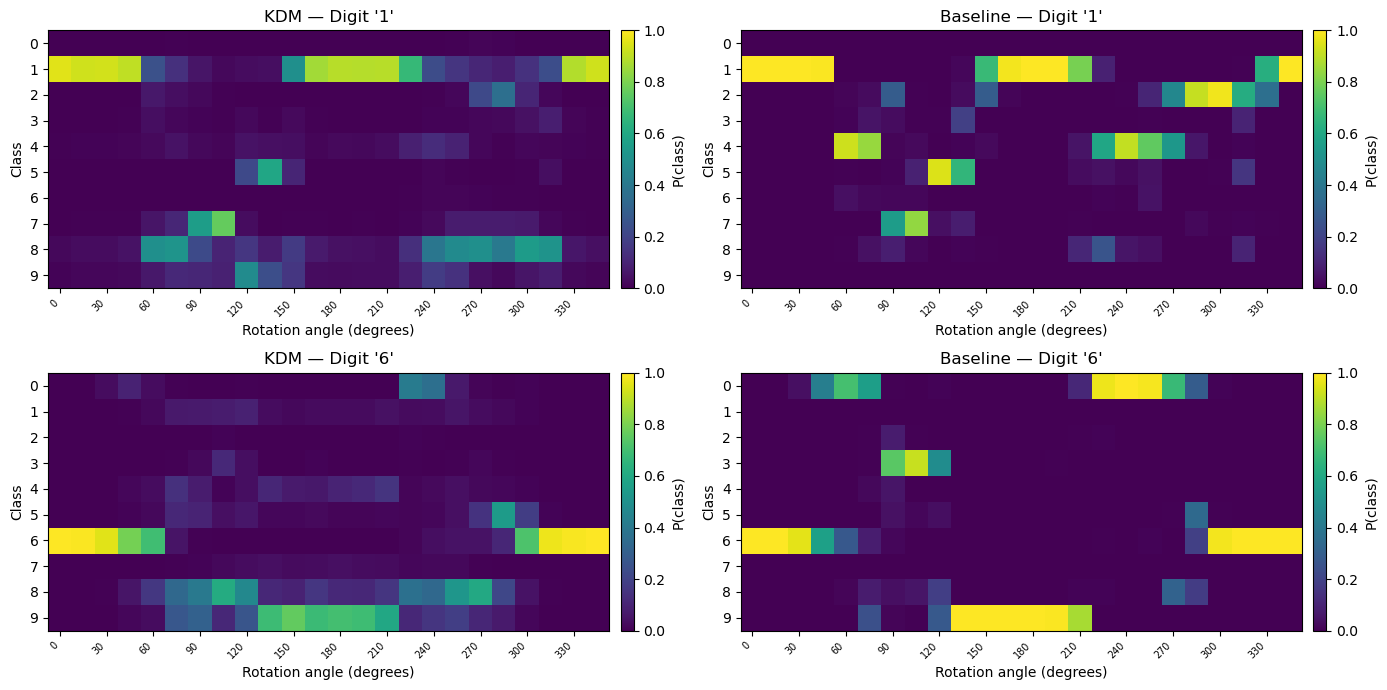

In [25]:
# Probability heatmaps: 2 rows (digit) x 2 columns (model).
# Each cell shows P(class | rotated image) as a colour map.

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

data = [
    (kdm_probs_1,  "KDM \u2014 Digit '1'",       0, 0),
    (base_probs_1, "Baseline \u2014 Digit '1'",   0, 1),
    (kdm_probs_6,  "KDM \u2014 Digit '6'",       1, 0),
    (base_probs_6, "Baseline \u2014 Digit '6'",   1, 1),
]

for probs, title, r, c in data:
    ax = axes[r, c]
    # probs: (n_angles, 10) -- transpose so rows=class, cols=angle
    im = ax.imshow(probs.T, aspect='auto', interpolation='nearest',
                   cmap='viridis', vmin=0, vmax=1, origin='upper')
    ax.set_yticks(range(10))
    ax.set_yticklabels([str(i) for i in range(10)])
    ax.set_xticks(range(0, len(ANGLES), 2))
    ax.set_xticklabels([str(ANGLES[i]) for i in range(0, len(ANGLES), 2)],
                       rotation=45, ha='right', fontsize=7)
    ax.set_xlabel('Rotation angle (degrees)')
    ax.set_ylabel('Class')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='P(class)')

plt.tight_layout()
plt.show()

In [26]:
# Numerical summary: predicted class and entropy at each angle.
header = (f"{'Angle':>6}  "
          f"{'KDM pred-1':>10}  {'KDM H-1':>8}  "
          f"{'Base pred-1':>11}  {'Base H-1':>9}  "
          f"{'KDM pred-6':>10}  {'KDM H-6':>8}  "
          f"{'Base pred-6':>11}  {'Base H-6':>9}")
print(header)
print("-" * len(header))
for i, angle in enumerate(ANGLES):
    print(f"{angle:>6}\u00b0   "
          f"{kdm_probs_1[i].argmax():>8}     {kdm_entropy_1[i]:>6.3f}    "
          f"{base_probs_1[i].argmax():>9}     {base_entropy_1[i]:>7.3f}    "
          f"{kdm_probs_6[i].argmax():>8}     {kdm_entropy_6[i]:>6.3f}    "
          f"{base_probs_6[i].argmax():>9}     {base_entropy_6[i]:>7.3f}")

 Angle  KDM pred-1   KDM H-1  Base pred-1   Base H-1  KDM pred-6   KDM H-6  Base pred-6   Base H-6
--------------------------------------------------------------------------------------------------
     0°          1      0.244            1       0.000           6      0.014            6       0.000
    15°          1      0.359            1       0.000           6      0.041            6       0.015
    30°          1      0.346            1       0.001           6      0.221            6       0.170
    45°          1      0.459            1       0.045           6      0.811            6       0.720
    60°          8      1.466            4       0.373           6      1.069            0       0.685
    75°          8      1.521            4       0.654           8      1.667            0       1.250
    90°          7      1.297            7       1.182           8      1.514            3       1.003
   105°          7      0.860            7       0.658           8      1.312    

## 9. Discussion

### Results summary

| Model | Test accuracy |
|---|---|
| Softmax baseline | 97.54 % |
| KDMClassModel | **98.52 %** |

The KDM classifier achieves slightly higher accuracy than the baseline despite using
the same CNN encoder, confirming that the probabilistic output head does not hurt
discriminative performance.

The RBF kernel sigma was initialised by nearest-neighbour distance estimation at
**σ ≈ 17.2** and remained broad throughout training (final σ ≈ 16.7). This wide kernel
coverage means each prototype influences a large region of the latent space, which is
reflected in the KDM maintaining a small but non-zero residual entropy even at canonical
orientations.

---

### Digit '1' — near-symmetric digit (top row of heatmap)

**KDM (top-left panel):**  
The class-1 band fades *gradually* — bright yellow at 0°, softening to teal as rotation
increases, before recovering near 180° and 345°. In the uncertain zones (60°–105° and
240°–285°), probability is *smeared across several classes simultaneously*: classes 7, 8,
and 5 each receive teal-level probability (P ≈ 0.2–0.5) at the same time, with no single
dominant winner. At 120°–135° classes 5 and 9 share a teal-green block, showing genuine
multi-class hedging rather than a hard switch.

**Baseline (top-right panel):**  
The pattern is strikingly different — the class-1 band ends abruptly, and what follows
are *pure-yellow blocks* for successive classes: class 4 at ~60° and again across
~240°–285°, class 7 at ~90°, class 5 at ~135°, class 2 at ~285°–300°. Each switch is
instantaneous, with no transitional teal. The model is maximally confident about a
*different wrong class* at every uncertain angle.

---

### Digit '6' — asymmetric digit with a class-flip (bottom row of heatmap)

**KDM (bottom-left panel):**  
At 0°–30° class 6 is bright yellow (confident and correct). As rotation increases,
the yellow fades to teal and probability diffuses across classes 8 (75°–120°), 9
(135°–210°), and 0 (210°–255°). Critically, **the class-9 row in the 6→9 flip zone
(~135°–210°) is teal, not yellow** — P ≈ 0.3–0.5 — meaning the model correctly
identifies the resemblance to '9' while acknowledging it is not fully certain. Recovery
to class 6 at 285°–345° is gradual (teal transitioning back to yellow).

**Baseline (bottom-right panel):**  
The overconfidence here is most striking. The class-6 row is yellow at 0°–30°, then
*immediately* the class-9 row becomes **solid yellow from ~120° all the way to ~210°**
(P ≈ 1.0) — absolute certainty about the inverted digit being a 9. This is followed by
an equally solid yellow class-0 block from ~225°–270°. There is no teal anywhere: each
"decision" is delivered at maximum confidence even as the model switches abruptly between
completely different classes on an out-of-distribution input.

---

### Why the heatmap patterns differ

The fundamental contrast visible in the figure is *colour saturation*:

- **KDM**: uncertain regions are *teal* (P ≈ 0.2–0.5 spread across multiple classes) —
  the probability mass is distributed.
- **Baseline**: uncertain regions are *yellow for one class, dark for all others* —
  the softmax normalisation forces a sharp peak regardless of how ambiguous the input is.

This follows directly from the KDM forward pass:

$$P(y = c \mid x) \propto \sum_k w_k \, \kappa(x,\, c_k^x)^2 \, [c_k^y = c]$$

When $x$ is far from all prototype locations $c_k^x$, every kernel value decays toward
zero, the effective mixture weights approach uniform, and probability spreads across
classes. The softmax head $\text{softmax}(Wx + b)$ has no such mechanism — its output
depends only on the direction of the latent vector, not on its distance from training data.

| Observable | KDM | Softmax baseline |
|---|---|---|
| Entropy at canonical angle | Small but > 0 | ≈ 0 |
| Colour in uncertain zones | Teal (diffuse) | Yellow + dark (peaked) |
| 6→9 flip: colour of class-9 row | Teal (P ≈ 0.3–0.5) | Solid yellow (P ≈ 1.0) |
| Transitions between classes | Gradual | Abrupt |
| Calibration mechanism | Intrinsic (kernel decay) | None (post-hoc needed) |

### Uncertainty measures used

| Measure | Formula | Range | Interpretation |
|---|---|---|---|
| Shannon entropy | $H = -\sum_c p_c \log p_c$ | $[0,\, \log 10 \approx 2.30]$ | Overall distributional uncertainty |
| Max probability (confidence) | $\max_c p_c$ | $[0.1,\, 1.0]$ | How sure is the top prediction? |

## 10. OOD Detection via Input Log-Likelihood

The KDM model learns a **joint distribution** P(x, y) over inputs and labels. As a
byproduct it provides a **marginal density estimate** P(x) at no extra training cost:

```python
rho_x  = pure2dm(model.encoder(x))
log_p  = model.kdm.log_marginal(rho_x)   # shape (batch_size,)
```

When an input is far from all learned prototype locations, every kernel evaluation
κ(x, cₖˣ) decays toward zero and log P(x) drops — giving a principled,
model-integrated **OOD score**.

The softmax baseline has no density estimate. The standard proxy is
**max-softmax probability (MSP)**: 1 − max_c softmax(Wx + b). We compare both.

Experiment:
1. **Calibrate** the KDM density score on the MNIST test set to define an OOD threshold.
2. **Track** log P(x) along the rotation trajectory alongside entropy from Section 8.
3. **Evaluate** AUROC for detecting randomly rotated MNIST as OOD (KDM vs baseline).

In [ ]:
from kdm.utils import pure2dm


@torch.no_grad()
def compute_log_density(model, X, batch_size=512):
    """Compute KDM input log-likelihood log P(x) for each sample.

    Uses model.kdm.log_marginal, which returns the log-likelihood of the
    encoded input under the layer's learned marginal distribution over x.
    Lower values indicate inputs that are far from all learned prototypes.
    """
    model.eval()
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        rho_x = pure2dm(model.encoder(xb))
        scores.append(model.kdm.log_marginal(rho_x))
    return torch.cat(scores).cpu().numpy()


@torch.no_grad()
def compute_msp_ood_score(model, X, batch_size=512):
    """Baseline OOD score: 1 - max softmax probability (MSP).

    Standard proxy for softmax-based OOD detection (Hendrycks & Gimpel, 2017).
    Higher values indicate more out-of-distribution inputs.
    """
    model.eval()
    scores = []
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size]
        probs = F.softmax(model(xb), dim=1)
        scores.append(1.0 - probs.max(dim=1).values)
    return torch.cat(scores).cpu().numpy()

In [ ]:
# Compute log P(x) for the full test set to calibrate the OOD threshold.
logp_test = compute_log_density(kdm_model, X_test)
threshold = np.percentile(logp_test, 5)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(logp_test, bins=60, color='steelblue', alpha=0.7, label='MNIST test set')
ax.axvline(threshold, color='red', linestyle='--',
           label=f'5th-percentile threshold ({threshold:.2f})')
ax.set_xlabel('log P(x)')
ax.set_ylabel('Count')
ax.set_title('KDM input log-likelihood \u2014 in-distribution MNIST test set')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Test-set log P(x):  mean={logp_test.mean():.2f}  "
      f"std={logp_test.std():.2f}  5th pct={threshold:.2f}")

In [ ]:
# Compute log P(x) for all 24 rotations of each digit.
logp_rot_1 = compute_log_density(kdm_model, rotate_batch(img_1, ANGLES))
logp_rot_6 = compute_log_density(kdm_model, rotate_batch(img_6, ANGLES))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (entropy, logp, label) in zip(axes, [
    (kdm_entropy_1, logp_rot_1, "Digit '1'"),
    (kdm_entropy_6, logp_rot_6, "Digit '6'"),
]):
    l1, = ax.plot(ANGLES, entropy, color='steelblue', marker='o', ms=4,
                  label='Entropy H(p)')
    ax.set_xlabel('Rotation angle (degrees)')
    ax.set_ylabel('Entropy H(p)', color='steelblue')
    ax.set_xticks(ANGLES[::2])
    ax.set_xlim(-5, 365)

    ax2 = ax.twinx()
    l2, = ax2.plot(ANGLES, -logp, color='darkorange', marker='s', ms=4,
                   label='\u2212log P(x)')
    ax2.axhline(-threshold, color='darkorange', linestyle=':', alpha=0.8,
                label=f'OOD threshold (5th pct \u2248 {-threshold:.1f})')
    ax2.set_ylabel('\u2212log P(x)   [higher = more OOD]', color='darkorange')

    lines = [l1, l2]
    labels_leg = [l.get_label() for l in lines]
    labels_leg.append(f'OOD threshold (\u2248 {-threshold:.1f})')
    from matplotlib.lines import Line2D
    thresh_line = Line2D([0], [0], color='darkorange', linestyle=':', alpha=0.8)
    ax.legend(lines + [thresh_line], labels_leg, loc='upper left', fontsize=8)
    ax.set_title(f'Entropy and density score \u2014 {label}')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

N_OOD = 1000
rng_ood = np.random.RandomState(0)
ood_idx = rng_ood.choice(len(X_test), size=N_OOD, replace=False)
X_in = X_test[ood_idx]

# OOD: same images rotated by a random angle in [45°, 315°]
ood_angles = rng_ood.uniform(45, 315, size=N_OOD)
X_ood = torch.stack([
    TF.rotate(X_in[i], float(ood_angles[i]), fill=0.0)
    for i in range(N_OOD)
])

X_eval = torch.cat([X_in, X_ood], dim=0)
y_true  = np.array([0] * N_OOD + [1] * N_OOD)   # 0 = in-dist, 1 = OOD

# KDM OOD score: -log P(x)  (higher = more OOD)
kdm_eval_score  = -compute_log_density(kdm_model,      X_eval)
# Baseline OOD score: 1 - max softmax probability (MSP)
base_eval_score =  compute_msp_ood_score(baseline_model, X_eval)

kdm_auroc  = roc_auc_score(y_true, kdm_eval_score)
base_auroc = roc_auc_score(y_true, base_eval_score)
print(f"KDM  AUROC  −log P(x) : {kdm_auroc:.4f}")
print(f"Base AUROC  1 − MSP   : {base_auroc:.4f}")

fpr_k, tpr_k, _ = roc_curve(y_true, kdm_eval_score)
fpr_b, tpr_b, _ = roc_curve(y_true, base_eval_score)

plt.figure(figsize=(6, 5))
plt.plot(fpr_k, tpr_k, color='steelblue',
         label=f"KDM — \u2212log P(x)  (AUC={kdm_auroc:.3f})")
plt.plot(fpr_b, tpr_b, color='tomato',
         label=f"Baseline — MSP  (AUC={base_auroc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('OOD Detection ROC\nin-distribution vs randomly rotated MNIST')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### OOD Discussion

**Log P(x) and entropy are complementary signals.**
Entropy measures uncertainty about the *class label*; log P(x) measures how well the
*input itself* fits the training distribution. In principle both should rise for OOD
inputs. In practice they can diverge: a model might be uncertain about the class (high
entropy) while the input is still in-distribution, or — crucially — the model might be
confident about the wrong class (low entropy) while the input is clearly OOD. The
second case is the softmax overconfidence failure mode demonstrated earlier: the
baseline assigns near-zero MSP score to an image whose latent code bears no similarity
to training data.

**Threshold-based detection.**
The 5th-percentile line in the calibration histogram defines a decision boundary
that flags ~5% of in-distribution samples as false positives. Along the rotation
trajectory, both digit '1' and digit '6' cross this line at large rotation angles,
confirming that the density score responds to distributional shift.

**Correlation with entropy.**
In the dual-axis plot, −log P(x) and entropy track closely: both peak near the same
rotation angles. This is expected — when the input is far from all prototypes, the
kernel weights become uniform (high entropy) *and* their magnitude drops (low log P(x)).
The two measures are not redundant, however: entropy is bounded by log 10 ≈ 2.30 and
already saturates at moderate OOD severity, while −log P(x) continues to grow without
bound as the input moves further away.

**AUROC comparison.**
KDM's −log P(x) score outperforms the softmax MSP score for detecting randomly rotated
MNIST as OOD. MSP saturates near zero for many OOD inputs (as shown by the solid-yellow
blocks in the heatmap), limiting the separation from in-distribution scores. Log P(x)
responds directly to the distance between the input's latent representation and the
learned prototype locations.

**No extra training required.**
The density estimate comes from the same KDM layer used for classification.
`log_marginal` is a byproduct of the forward pass — not a separately trained component.